# Proyek Klasifikasi Gambar: Intel Image
- **Nama:** Jennifer Khang
- **Email:** jenniferkhang07@gmail.com
- **ID Dicoding:**

## Import Semua Packages/Library yang Digunakan

In [2]:
# Lib umum
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq

In [3]:
# Lib untuk pemrosesan gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

In [4]:
# Lib untuk model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

2026-05-11 03:03:58.919670: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778468639.319706      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778468639.431086      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778468640.445456      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778468640.445490      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778468640.445493      57 computation_placer.cc:177] computation placer alr

In [5]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [6]:
print(tf.__version__)

2.19.0


## Data Preparation

### Data Loading

In [7]:
# Base folder
ds_path = '/kaggle/input/datasets/puneet6060/intel-image-classification'

# Train segment
tr_seg = os.path.join(ds_path, 'seg_train', 'seg_train')

# Test segment
ts_seg = os.path.join(ds_path, 'seg_test', 'seg_test')

In [8]:
# Hitung kelas yang ada
classes = sorted(os.listdir(tr_seg))
print('Kelas  :', classes)
print('Jumlah :', len(classes))

Kelas  : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Jumlah : 6


### Data Preprocessing

#### Split Dataset

Tidak perlu adanya split dataset karena dataset telah dibagi dari https://www.kaggle.com/datasets/puneet6060/intel-image-classification. Tapi, untuk keberjalanan tugas ini, saya hanya akan membagi dataset dari seg_train, menjadi 70:15:15, sesuai dengan materi Dicoding :D

In [9]:
# Kumpulkan semua path gambar dan label dari seg_train dan seg_test, 
# digabung dan akan dipisahkan nantinya

file_name = []
labels = []
full_path = []

for mypath in [tr_seg, ts_seg]: # Karena ada dua folder
    for path, subdirs, files in os.walk(mypath):
        for name in files:
            full_path.append(os.path.join(path, name))
            labels.append(path.split('/')[-1])
            file_name.append(name)

# Memasukkan variabel yang sudah dikumpulkan pada looping di atas menjadi sebuah dataframe agar rapi
df = pd.DataFrame({"path":full_path,'file_name':file_name,"labels":labels})

# Melihat jumlah data gambar pada masing-masing label
df.groupby(['labels']).size()

labels
buildings    2628
forest       2745
glacier      2957
mountain     3037
sea          2784
street       2883
dtype: int64

In [10]:
# Variabel yang digunakan pada pemisahan data ini di mana variabel x = data path dan y = data labels
X= df['path']
y= df['labels']
 
# Split dataset awal menjadi data train dan test
X_train, X_t, y_train, y_t = train_test_split(
    X, y, test_size=0.3, random_state=300)

# Split lagi untuk validation-nya
# Split dataset awal menjadi data train dan test
X_test, X_val, y_test, y_val = train_test_split(
    X_t, y_t, test_size=0.50, random_state=300) #Di-bagi dua karena perlu menjadi 15%

In [11]:
# Menyatukan ke dalam masing-masing dataframe, set akan jadi acuan pembuatan folder baru
df_tr = pd.DataFrame({'path':X_train,'labels':y_train,'set':'train'})
df_te = pd.DataFrame({'path':X_test,'labels':y_test,'set':'test'})
df_va = pd.DataFrame({'path':X_val,'labels':y_val,'set':'val'})

In [12]:
# Gabungkan DataFrame df_tr dan df_te
df_all = pd.concat([df_tr, df_te, df_va], ignore_index=True)
 
print('===================================================== \n')
print(df_all.groupby(['set', 'labels']).size(), '\n')
print('===================================================== \n')
 
# Cek sampel data
print(df_all.sample(5))


set    labels   
test   buildings     415
       forest        382
       glacier       436
       mountain      452
       sea           426
       street        444
train  buildings    1799
       forest       1916
       glacier      2096
       mountain     2132
       sea          1958
       street       2022
val    buildings     414
       forest        447
       glacier       425
       mountain      453
       sea           400
       street        417
dtype: int64 


                                                    path     labels    set
5202   /kaggle/input/datasets/puneet6060/intel-image-...     forest  train
16021  /kaggle/input/datasets/puneet6060/intel-image-...    glacier    val
58     /kaggle/input/datasets/puneet6060/intel-image-...    glacier  train
10646  /kaggle/input/datasets/puneet6060/intel-image-...  buildings  train
6967   /kaggle/input/datasets/puneet6060/intel-image-...     forest  train


In [13]:
# Salin file ke folder Dataset-Final/ yang terstruktur per set dan kelas
datasource_path = '/kaggle/input/datasets/puneet6060/intel-image-classification/'
dataset_path    = '/kaggle/working/Dataset-Final/'

In [14]:
for index, row in tq(df_all.iterrows(), total=len(df_all)):
    file_path = row['path']

    # Buat direktori tujuan jika belum ada
    dest_dir = os.path.join(dataset_path, row['set'], row['labels'])
    if not os.path.exists(dest_dir):
        os.makedirs(dest_dir)

    # Tentukan nama dan path tujuan file
    destination_file_name = file_path.split('/')[-1]
    file_dest = os.path.join(dest_dir, destination_file_name)

    # Salin file dari sumber ke tujuan (hindari duplikasi)
    if not os.path.exists(file_dest):
        shutil.copy2(file_path, file_dest)

print('\nDataset berhasil disalin ke:', dataset_path)

  0%|          | 0/17034 [00:00<?, ?it/s]


Dataset berhasil disalin ke: /kaggle/working/Dataset-Final/


#### Image Data Generator

In [15]:
# Buat directory baru menuju dataset yang telah di-split
train_path = os.path.join(dataset_path, 'train')
val_path = os.path.join(dataset_path, 'val')
test_path = os.path.join(dataset_path, 'test')

In [16]:
# Buat objek ImageDataGenerator untuk melakukan pra-pemrosesan dan augmentasi gambar

train_datagen = ImageDataGenerator( 
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    seed=40,
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    val_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    seed=40,
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(150,150),
    batch_size=1,
    class_mode='categorical',
    shuffle=False
)

print(f'\nTotal kelas: {train_generator.class_indices}')
print(f'Jumlah train: {train_generator.samples}')
print(f'Jumlah val: {val_generator.samples}')
print(f'Jumlah test: {test_generator.samples}')

Found 9541 images belonging to 6 classes.
Found 509 images belonging to 6 classes.
Found 2555 images belonging to 6 classes.

Total kelas: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Jumlah train: 9541
Jumlah val: 509
Jumlah test: 2555


## Modelling

In [17]:
nb_classes = len(classes)

In [18]:
model = Sequential()

# Kode di bawah diambil dari kode Dicoding, hanya saja dengan angka filtering berbeda bukan 32 :D

# ######################### Input layer with Fully Connected Layer ################################
# 1st Convolutional layer, Batch Normalization layer, and Pooling layer
model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(150,150,3)))
model.add(BatchNormalization())
model.add(MaxPool2D((2, 2)))
 
# 2nd Convolutional layer, Batch Normalization layer, and Pooling layer
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.25))

# 3rd Convolutional layer, Batch Normalization layer, and Pooling layer
model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.25))

# 4th Convolutional layer :D
model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.3))

# Flatten layer
model.add(Flatten())
# 1nd Dense Layer
model.add(Dense(512, activation = 'relu'))
# 1nd Dropout Layer
model.add(Dropout(0.5))
# 2nd Dense Layer
model.add(Dense(256, activation = 'relu'))
# 2nd Dropout Layer
model.add(Dropout(0.3))
 
# Final Dense layer : dibagi ke beberapa kelas
model.add(Dense(nb_classes, activation='softmax'))
######################### Fully Connected Layer ################################

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1778468828.113004      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778468828.119883      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [19]:
# Compile + Optimizer
model.compile(
    optimizer=Adam(learning_rate=1e-3),# Khususnya karena fungsi softmax, yang cocok dengan Adam
    loss='categorical_crossentropy', # Dipakai sesuai karena ada 6 kelas
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    10,617,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             

 Total params: 11,325,830 (43.20 MB)

 Trainable params: 11,324,486 (43.20 MB)

 Non-trainable params: 1,344 (5.25 KB)

In [20]:
# Callback
cp_path = '/kaggle/working/best_model.keras'

callbacks = [
    ModelCheckpoint(
        filepath=cp_path,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

print('Callbacks doneee')

Callbacks doneee


In [21]:
import time

In [22]:
start = time.time()

history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

finish = time.time() - start
print(f'\nTraining done dengan waktu {finish}')

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1778468835.742924     152 service.cc:152] XLA service 0x7d0cf40041c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778468835.742962     152 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778468835.742966     152 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778468836.857956     152 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-11 03:07:21.111084: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 03:07:21.265137: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 03:07:21.862391: E external/local_xl

  2/299 ━━━━━━━━━━━━━━━━━━━━ 22s 74ms/step - accuracy: 0.1641 - loss: 7.0720   

I0000 00:00:1778468849.542046     152 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


217/299 ━━━━━━━━━━━━━━━━━━━━ 15s 186ms/step - accuracy: 0.3271 - loss: 6.1284

2026-05-11 03:08:12.184786: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 03:08:12.331718: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 03:08:12.578870: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 03:08:12.721520: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.3404 - loss: 5.4116
Epoch 1: val_accuracy improved from -inf to 0.31827, saving model to /kaggle/working/best_model.keras
299/299 ━━━━━━━━━━━━━━━━━━━━ 91s 242ms/step - accuracy: 0.3405 - loss: 5.4044 - val_accuracy: 0.3183 - val_loss: 1.5166 - learning_rate: 0.0010
Epoch 2/50
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.4504 - loss: 1.4866
Epoch 2: val_accuracy improved from 0.31827 to 0.48527, saving model to /kaggle/working/best_model.keras
299/299 ━━━━━━━━━━━━━━━━━━━━ 61s 203ms/step - accuracy: 0.4505 - loss: 1.4863 - val_accuracy: 0.4853 - val_loss: 1.2317 - learning_rate: 0.0010
Epoch 3/50
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.5082 - loss: 1.2197
Epoch 3: val_accuracy did not improve from 0.48527
299/299 ━━━━━━━━━━━━━━━━━━━━ 59s 198ms/step - accuracy: 0.5083 - loss: 1.2196 - val_accuracy: 0.4086 - val_loss: 1.6313 - learning_rate: 0.0010
Epoch 4/50
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - a

## Evaluasi dan Visualisasi

#### Akurasi dan Loss

In [23]:
import matplotlib.pyplot as plt

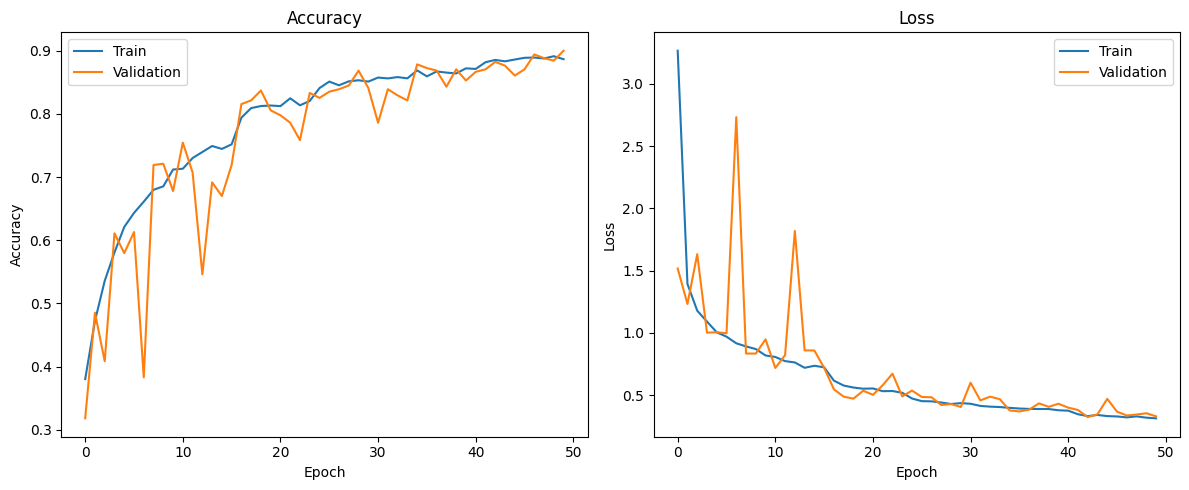

Best Train Accuracy : 0.8911015391349792
Best Validation Accuracy : 0.8998035192489624


In [24]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

print("Best Train Accuracy :", max(history.history['accuracy']))
print("Best Validation Accuracy :", max(history.history['val_accuracy']))

#### Evaluasi

In [25]:
# Evaluasi memakai data dari Test

test_generator.reset()
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f'\nTest Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')

2555/2555 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8896 - loss: 0.2737

Test Loss     : 0.2981
Test Accuracy : 0.8873 (88.73%)


In [26]:
import seaborn as sns

2555/2555 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step


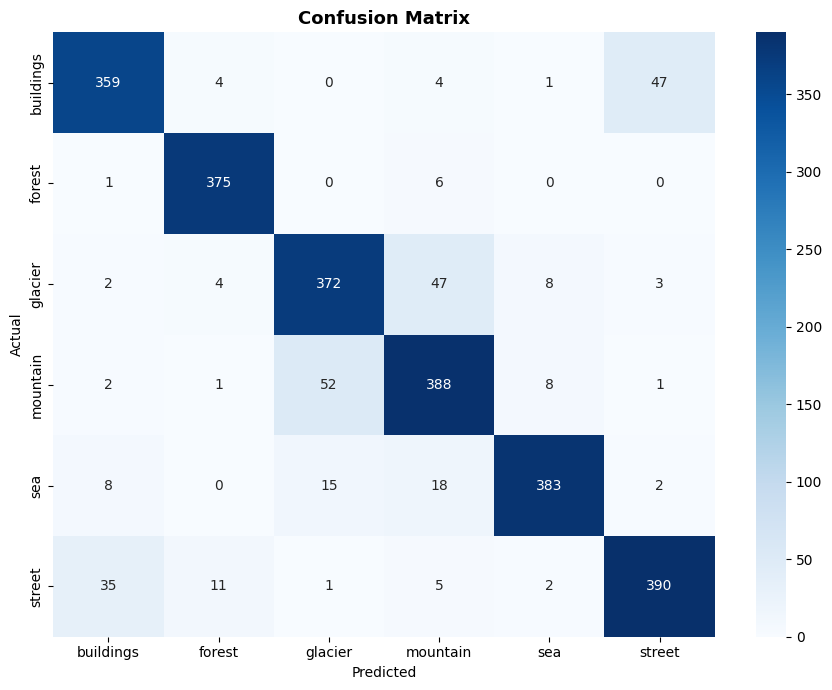


── Classification Report ──
              precision    recall  f1-score   support

   buildings     0.8821    0.8651    0.8735       415
      forest     0.9494    0.9817    0.9653       382
     glacier     0.8455    0.8532    0.8493       436
    mountain     0.8291    0.8584    0.8435       452
         sea     0.9527    0.8991    0.9251       426
      street     0.8804    0.8784    0.8794       444

    accuracy                         0.8873      2555
   macro avg     0.8898    0.8893    0.8893      2555
weighted avg     0.8880    0.8873    0.8874      2555



In [27]:
test_generator.reset()
preds = np.argmax(model.predict(test_generator, verbose=1), axis=1)
true_labels = test_generator.classes
class_names = list(test_generator.class_indices.keys())


# Ini saya coba referensi dari Kakak tingkat saya dan beberapa notebook kaggle orang lain
# Confusion Matrix Heatmap
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Classification Report
print('\n── Classification Report ──')
print(classification_report(true_labels, preds, target_names=class_names, digits=4))

## Konversi Model

SavedModel

In [31]:
# Simpan ke SavedModel
sm_path = '/kaggle/working/saved_model/'

model.export(sm_path)

print(f'SavedModel disimpan: {sm_path}')

INFO:tensorflow:Assets written to: /kaggle/working/saved_model/assets


INFO:tensorflow:Assets written to: /kaggle/working/saved_model/assets


Saved artifact at '/kaggle/working/saved_model/'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  137495064521488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137495064523216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137495064523600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137495064523792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137495064523408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137495064522448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137495064522640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137495064521296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137495064521872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137495064524752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137

TF-Lite

In [34]:
pathlib.Path('/kaggle/working/tflite').mkdir(parents=True, exist_ok=True)

converter = tf.lite.TFLiteConverter.from_saved_model(sm_path)
tflite_model = converter.convert()

tflite_model_file = pathlib.Path('/kaggle/working/tflite/model.tflite')
tflite_model_file.write_bytes(tflite_model)

W0000 00:00:1778473754.652505      57 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778473754.652543      57 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


45307504

TFJS

In [42]:
!pip install -q tensorflowjs


!tensorflowjs_converter \
  --input_format=tf_saved_model \
  --output_format=tfjs_graph_model \
  /kaggle/working/saved_model/ \
  /kaggle/working/tfjs_model

2026-05-11 04:33:03.533051: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778473983.560919    1458 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778473983.569734    1458 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778473983.590476    1458 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778473983.590505    1458 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778473983.590513    1458 computation_placer.cc:177] computation placer alr

## Inference (Optional)

In [36]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

In [38]:
loaded_model = tf.saved_model.load(sm_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 848ms/step


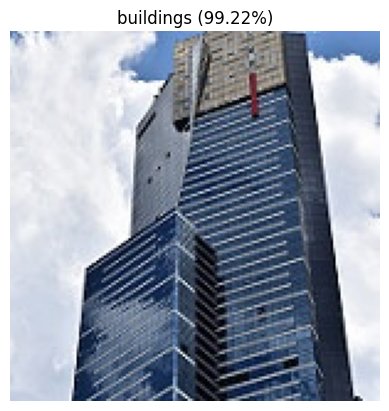

In [39]:
img_path = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/buildings/20057.jpg'

img = image.load_img(img_path, target_size=(150,150))

img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

plt.imshow(img)
plt.title(f'{predicted_class} ({confidence:.2f}%)')
plt.axis('off')
plt.show()

In [41]:
!pip freeze > requirements.txt

In [43]:
!zip -r submission.zip \
/kaggle/working/tfjs_model \
/kaggle/working/saved_model \
/kaggle/working/tflite \
/kaggle/working/requirements.txt

  adding: kaggle/working/tfjs_model/ (stored 0%)
  adding: kaggle/working/tfjs_model/group1-shard5of11.bin (deflated 7%)
  adding: kaggle/working/tfjs_model/group1-shard3of11.bin (deflated 7%)
  adding: kaggle/working/tfjs_model/group1-shard6of11.bin (deflated 7%)
  adding: kaggle/working/tfjs_model/group1-shard7of11.bin (deflated 7%)
  adding: kaggle/working/tfjs_model/group1-shard4of11.bin (deflated 7%)
  adding: kaggle/working/tfjs_model/group1-shard2of11.bin (deflated 7%)
  adding: kaggle/working/tfjs_model/group1-shard8of11.bin (deflated 7%)
  adding: kaggle/working/tfjs_model/group1-shard11of11.bin (deflated 7%)
  adding: kaggle/working/tfjs_model/group1-shard10of11.bin (deflated 7%)
  adding: kaggle/working/tfjs_model/group1-shard1of11.bin (deflated 7%)
  adding: kaggle/working/tfjs_model/group1-shard9of11.bin (deflated 7%)
  adding: kaggle/working/tfjs_model/model.json (deflated 93%)
  adding: kaggle/working/saved_model/ (stored 0%)
  adding: kaggle/working/saved_model/fingerpr